In [1]:
!pwd

/mnt/c/Users/vasil/Desktop/lncAPNet/notebooks/Post-hoc_Analysis


In [2]:
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

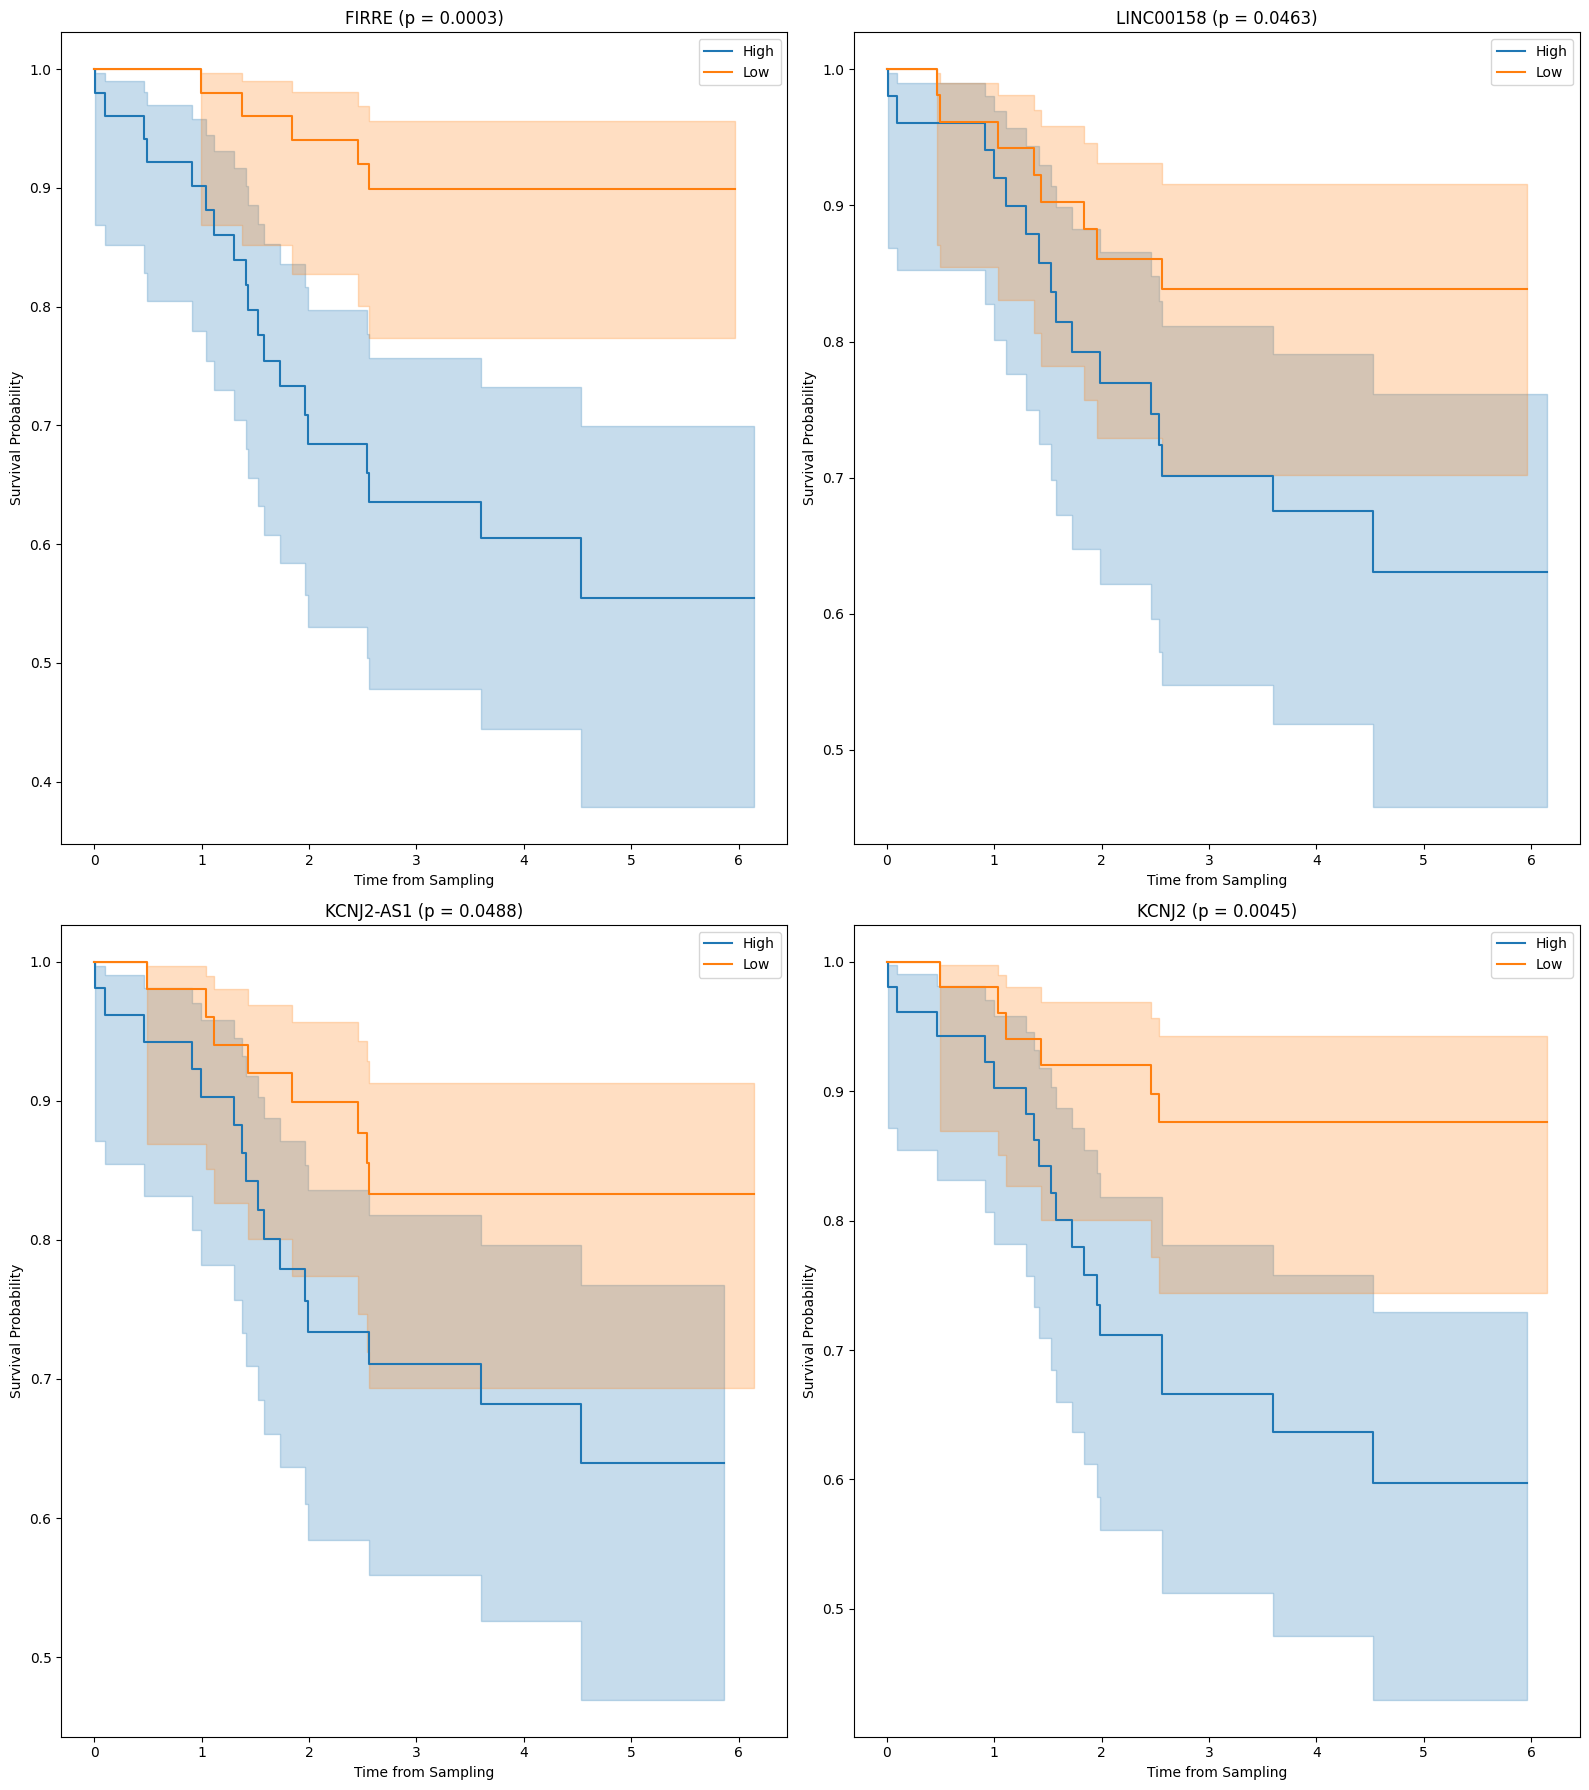

In [3]:
## Survival Status all genes BCMO
# 1. Load metadata
clinical = pd.read_csv("../../data/BCMO/clinical_info.csv")
clinical = clinical.rename(columns={"died": "Status"})

# 2. Load expression matrix
expr = pd.read_csv("../../data/BCMO/count_matrix.csv", index_col=0)

# 3. Genes of interest
genes = ["FIRRE", "LINC00158","KCNJ2-AS1", "KCNJ2"]

# 4. Set up 3x2 figure
fig, axes = plt.subplots(2, 2, figsize=(16, 18))
axes = axes.flatten()

for i, gene in enumerate(genes):
    ax = axes[i]
    
    if gene not in expr.index:
        ax.text(0.5, 0.5, f"{gene} not found", ha='center', va='center', fontsize=14)
        ax.axis('off')
        continue
    
    # Extract gene expression
    gene_expr = expr.loc[gene].rename("Expression")
    
    # Merge with clinical data
    df = clinical.merge(gene_expr, left_on="Sample_ID", right_index=True)
    
    # Stratify by median
    df[f"{gene}_group"] = (df["Expression"] > df["Expression"].median()).map({True: "High", False: "Low"})
    
    # Kaplan–Meier plot
    kmf = KaplanMeierFitter()
    for group, grouped_df in df.groupby(f"{gene}_group"):
        kmf.fit(grouped_df["OS.from.sampling"], grouped_df["Status"], label=group)
        kmf.plot_survival_function(ax=ax, ci_show=True)
    
    # Log-rank test
    high = df[df[f"{gene}_group"] == "High"]
    low = df[df[f"{gene}_group"] == "Low"]
    results = logrank_test(
        high["OS.from.sampling"], low["OS.from.sampling"],
        event_observed_A=high["Status"], event_observed_B=low["Status"]
    )
    pval = results.p_value
    
    ax.set_title(f"{gene} (p = {pval:.4f})")
    ax.set_xlabel("Time from Sampling")
    ax.set_ylabel("Survival Probability")

plt.tight_layout()
plt.savefig("../../figures/KaplanMeier_OS_all_genes_BCMO.png", dpi=300)
plt.show()

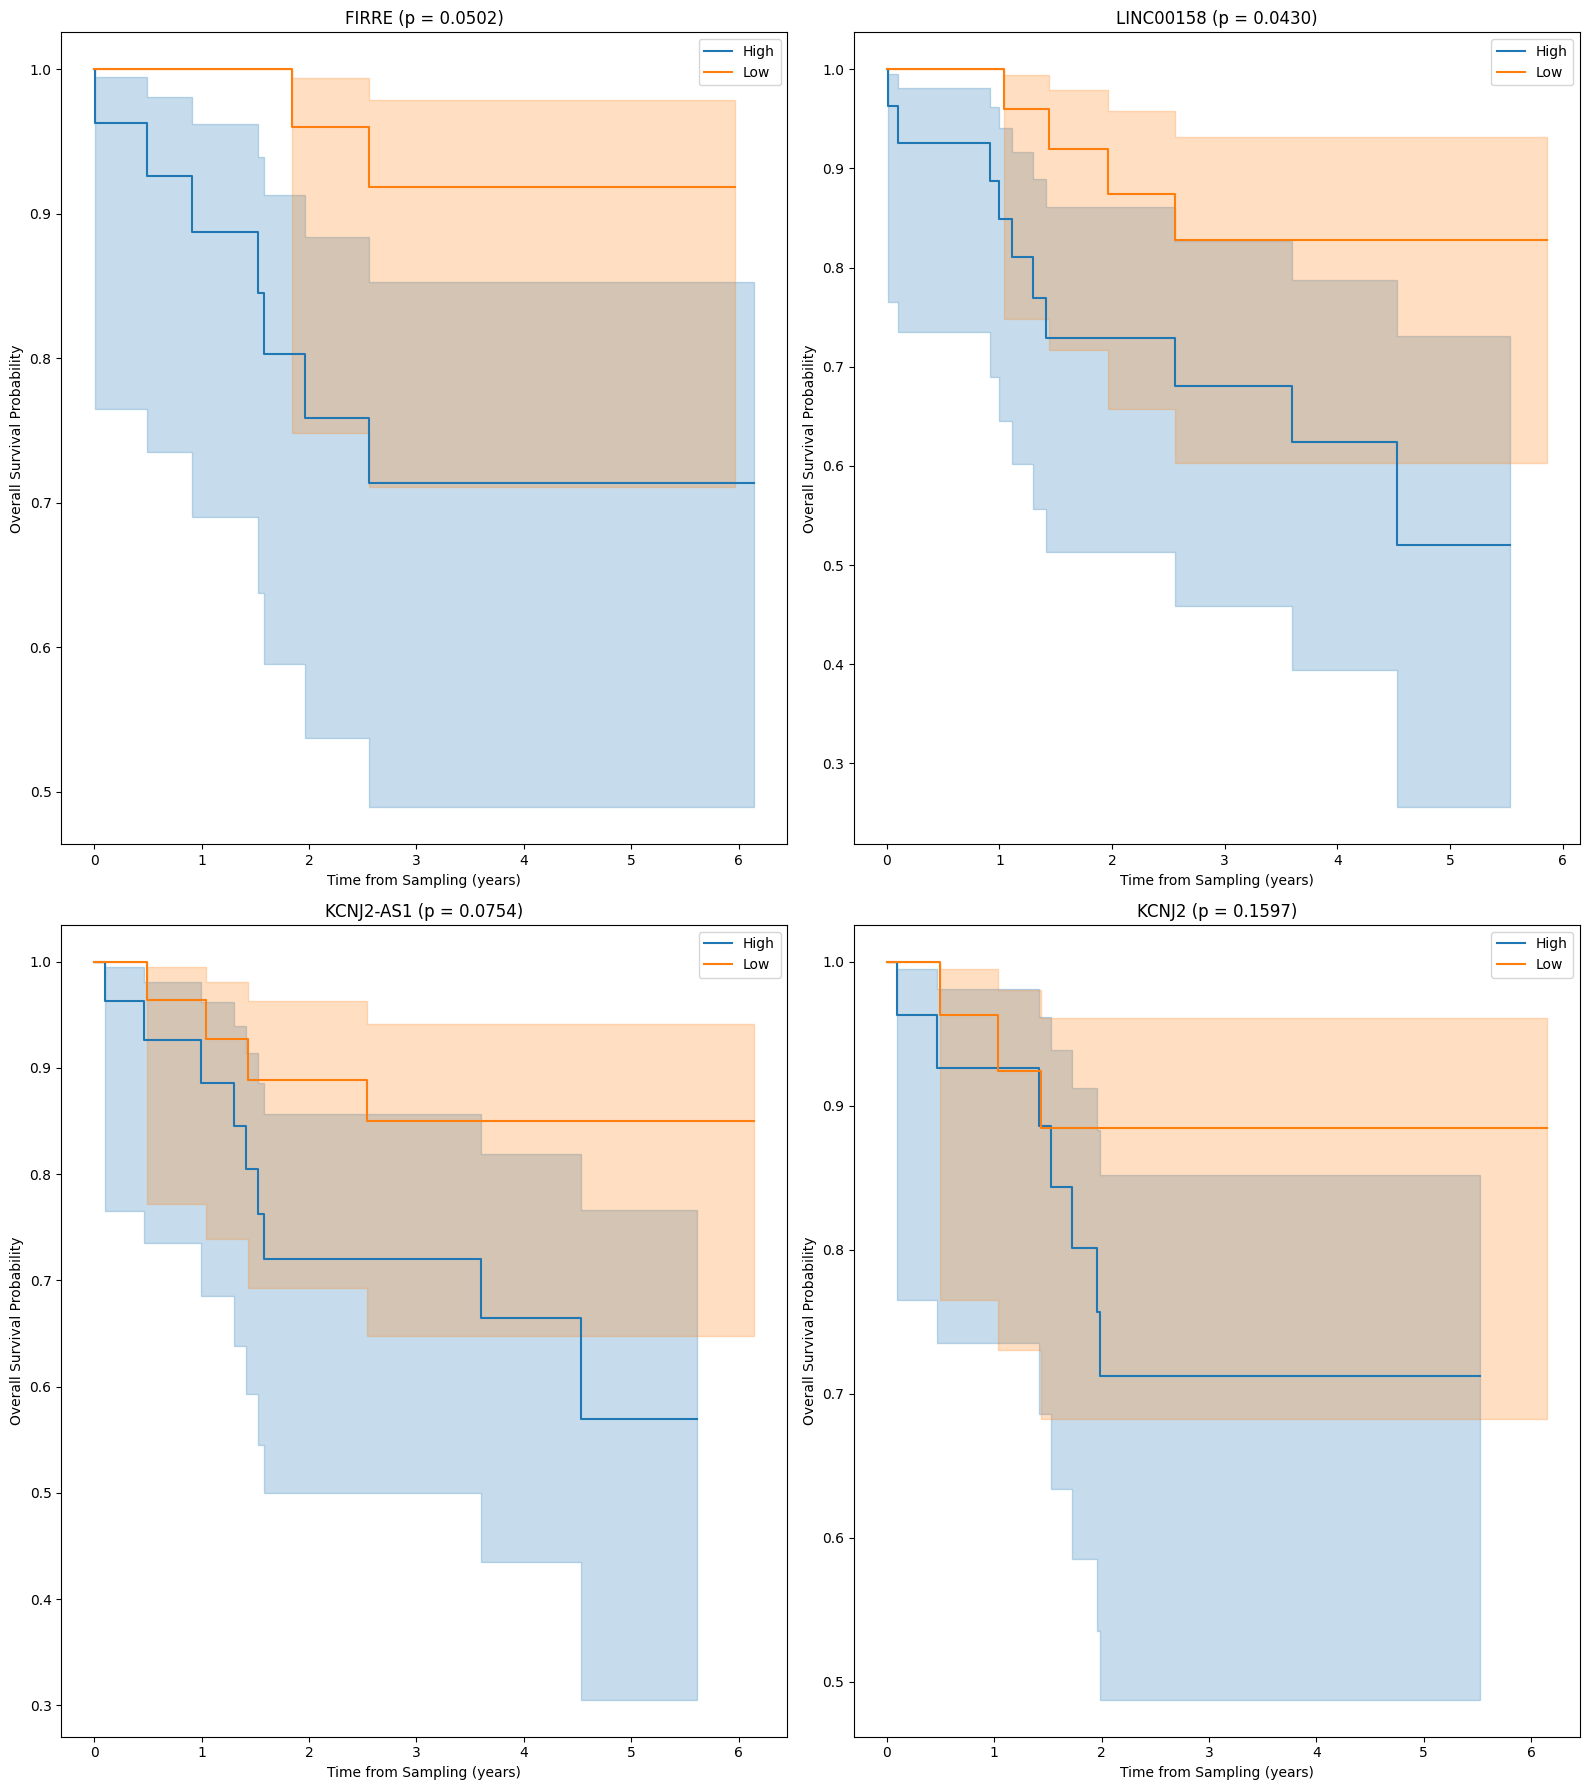

In [4]:
# Survival status quartile genes (OS) BCMO
# 1. Load metadata
clinical = pd.read_csv("../../data/BCMO/clinical_info.csv")
clinical = clinical.rename(columns={"died": "Status"})

# 2. Load expression matrix
expr = pd.read_csv("../../data/BCMO/count_matrix.csv", index_col=0)

# 3. Genes of interest
genes = ["FIRRE", "LINC00158", "KCNJ2-AS1", "KCNJ2"]

# 4. Set up 3x2 figure
fig, axes = plt.subplots(2, 2, figsize=(16, 18))
axes = axes.flatten()

# 5. Time column for Kaplan–Meier (Overall Survival)
time_col = "OS.from.sampling"

# 6. Loop through genes
for i, gene in enumerate(genes):
    ax = axes[i]
    
    if gene not in expr.index:
        ax.text(0.5, 0.5, f"{gene} not found", ha='center', va='center', fontsize=14)
        ax.axis('off')
        continue
    
    # Extract gene expression
    gene_expr = expr.loc[gene].rename("Expression")
    
    # Merge with clinical data
    df = clinical.merge(gene_expr, left_on="Sample_ID", right_index=True)
    
    # Determine top 25% and bottom 25%
    q_low = df["Expression"].quantile(0.25)
    q_high = df["Expression"].quantile(0.75)
    
    df_filtered = df[(df["Expression"] <= q_low) | (df["Expression"] >= q_high)].copy()
    df_filtered[f"{gene}_group"] = df_filtered["Expression"].apply(
        lambda x: "High" if x >= q_high else "Low"
    )
    
    # Kaplan–Meier plot
    kmf = KaplanMeierFitter()
    for group, grouped_df in df_filtered.groupby(f"{gene}_group"):
        kmf.fit(grouped_df[time_col], grouped_df["Status"], label=group)
        kmf.plot_survival_function(ax=ax, ci_show=True)
    
    # Log-rank test
    high = df_filtered[df_filtered[f"{gene}_group"] == "High"]
    low = df_filtered[df_filtered[f"{gene}_group"] == "Low"]
    results = logrank_test(
        high[time_col], low[time_col],
        event_observed_A=high["Status"], event_observed_B=low["Status"]
    )
    pval = results.p_value
    
    ax.set_title(f"{gene} (p = {pval:.4f})")
    ax.set_xlabel("Time from Sampling (years)")
    ax.set_ylabel("Overall Survival Probability")

plt.tight_layout()
plt.savefig("../../figures/KaplanMeier_OS_quartile_genes_BCMO.png", dpi=300)
plt.show()